# Deep learning for computer vision


This notebook will teach you to build and train convolutional networks for image recognition. Brace yourselves.

# CIFAR dataset
This week, we shall focus on the image recognition problem on cifar10 dataset
* 60k images of shape 3x32x32
* 10 different classes: planes, dogs, cats, trucks, etc.

<img src="https://github.com/yandexdataschool/deep_vision_and_graphics/blob/fall22/week02-convnets/cifar10.jpg?raw=1" style="width:80%">

In [1]:
# **IMPORTANT** when running in colab, un-comment this
!wget https://raw.githubusercontent.com/yandexdataschool/Practical_DL/refs/heads/fall25/week03_convnets/cifar.py
!wget https://github.com/justheuristic/junk/raw/refs/heads/cifar10-part/dataset.tar.part-aa
!wget https://github.com/justheuristic/junk/raw/refs/heads/cifar10-part/dataset.tar.part-ab
!wget https://github.com/justheuristic/junk/raw/refs/heads/cifar10-part/dataset.tar.part-ac
!wget https://github.com/justheuristic/junk/raw/refs/heads/cifar10-part/dataset.tar.part-ad
!cat dataset.tar.part-* | tar -xvf -
!mkdir cifar_data
!mv dataset/cifar-10-batches-py/  cifar_data/cifar-10-batches-py/

--2026-09-29 17:43:50--  https://raw.githubusercontent.com/yandexdataschool/Practical_DL/refs/heads/fall25/week03_convnets/cifar.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2396 (2.3K) [text/plain]
Saving to: ‘cifar.py’

cifar.py            100%[===================>]   2.34K  --.-KB/s    in 0s      

2026-09-29 17:43:51 (32.5 MB/s) - ‘cifar.py’ saved [2396/2396]

--2026-09-29 17:43:51--  https://github.com/justheuristic/junk/raw/refs/heads/cifar10-part/dataset.tar.part-aa
Resolving github.com (github.com)... 20.29.134.23
Connecting to github.com (github.com)|20.29.134.23|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/justheuristic/junk/refs/heads/cifar10-part/dataset.tar.part-aa [follow

In [2]:
import numpy as np
from cifar import load_cifar10
X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")

class_names = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck'])

print(X_train.shape,y_train.shape)

(40000, 3, 32, 32) (40000,)


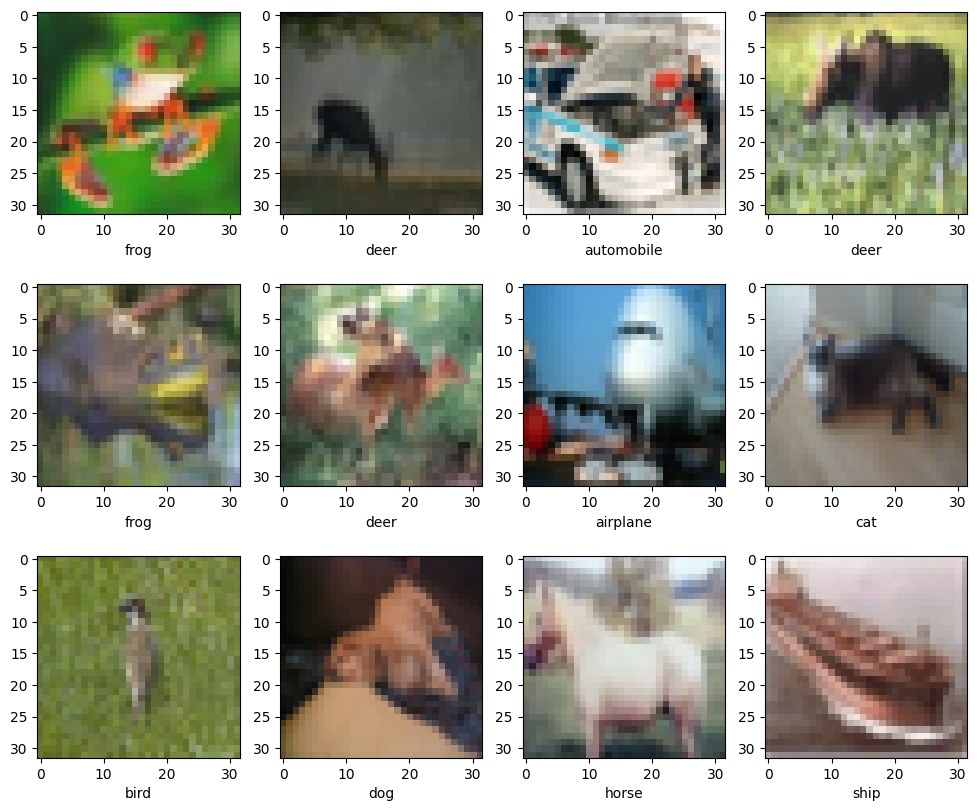

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.xlabel(class_names[y_train[i]])
    plt.imshow(np.transpose(X_train[i],[1,2,0]))

# Building a network

Simple neural networks with layers applied on top of one another can be implemented as `torch.nn.Sequential` - just add a list of pre-built modules and let it train.

Let's start with a dense network for our baseline, then gradually improve it.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

model = nn.Sequential(
    nn.Flatten(),  # reshape images to vectors; if you have conv / pool layers, they go BEFORE flatten
    nn.Linear(3 * 32 * 32, 128),
    nn.ReLU(),
    nn.Linear(128, 10) # logits for 10 classes. No softmax - this is intentional
)

As in our basic tutorial, we train our model with negative log-likelihood aka crossentropy.

In [5]:
def compute_loss(X_batch, y_batch):
    X_batch = torch.as_tensor(X_batch, dtype=torch.float32)
    y_batch = torch.as_tensor(y_batch, dtype=torch.int64)
    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()

In [6]:
# example
compute_loss(X_train[:5], y_train[:5])

tensor(2.2862, grad_fn=<MeanBackward0>)

### Training on minibatches
* We got 40k images, that's way too many for a full-batch SGD. Let's train on minibatches instead
* Below is a function that splits the training sample into minibatches

In [7]:
opt = torch.optim.SGD(model.parameters(), lr=0.01)

train_loss = []
val_accuracy = []

# An auxilary function that returns mini-batches for neural network training
def iterate_minibatches(X, y, batchsize):
    indices = np.random.permutation(np.arange(len(X)))
    for start in range(0, len(indices), batchsize):
        ix = indices[start: start + batchsize]
        yield X[ix], y[ix]

In [8]:
import time
num_epochs = 100 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item())  # .item() = convert 1-value Tensor to float

    # And a full pass over the validation data:
    model.train(False)     # disable dropout / use averages for batch_norm
    with torch.no_grad():  # do not store intermediate activations
        for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
            y_pred = logits.argmax(-1).detach().numpy()
            val_accuracy.append(np.mean(y_batch == y_pred))

    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 100 took 3.126s
  training loss (in-iteration): 	2.028566
  validation accuracy: 			32.48 %
Epoch 2 of 100 took 3.124s
  training loss (in-iteration): 	1.850656
  validation accuracy: 			35.45 %
Epoch 3 of 100 took 4.141s
  training loss (in-iteration): 	1.781003
  validation accuracy: 			38.79 %
Epoch 4 of 100 took 3.057s
  training loss (in-iteration): 	1.731095
  validation accuracy: 			40.44 %
Epoch 5 of 100 took 3.024s
  training loss (in-iteration): 	1.687699
  validation accuracy: 			41.85 %
Epoch 6 of 100 took 2.830s
  training loss (in-iteration): 	1.648920
  validation accuracy: 			42.38 %
Epoch 7 of 100 took 3.978s
  training loss (in-iteration): 	1.619044
  validation accuracy: 			43.85 %
Epoch 8 of 100 took 2.808s
  training loss (in-iteration): 	1.591333
  validation accuracy: 			43.48 %
Epoch 9 of 100 took 2.758s
  training loss (in-iteration): 	1.569503
  validation accuracy: 			45.51 %
Epoch 10 of 100 took 2.688s
  training loss (in-iteration): 	1.548573
  v

Don't wait for full 100 epochs. You can interrupt training after 5-20 epochs once validation accuracy stops going up.
```

```

```

```

```

```

```

```

```

```

### Final test

In [9]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		51.57 %
Achievement unlocked: 60lvl Warlock!


## Task I: small convolution net
### First step

Let's create a mini-convolutional network with roughly such architecture:
* Input layer
* 3x3 convolution with 10 filters and _ReLU_ activation
* 2x2 pooling (or set previous convolution stride to 3)
* Flatten
* Dense layer with 100 neurons and _ReLU_ activation
* 10% dropout
* Output dense layer.


__Convolutional layers__ in torch are just like all other layers, but with a specific set of parameters:

__`...`__

__`model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)) # convolution`__

__`model.add_module('pool1', nn.MaxPool2d(2)) # max pooling 2x2`__

__`...`__


Once you're done (and compute_loss no longer raises errors), train it with __Adam__ optimizer with default params (feel free to modify the code above).

If everything is right, you should get at least __50%__ validation accuracy.

In [10]:
model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))
model.add_module('flatten', nn.Flatten())
model.add_module('fc1', nn.Linear(10 * 15 * 15, 100))
model.add_module('relu2', nn.ReLU())
model.add_module('drop', nn.Dropout(0.1))
model.add_module('out', nn.Linear(100, 10))

In [12]:
opt = torch.optim.Adam(model.parameters())   # default lr=1e-3
train_loss = []
val_accuracy = []

In [17]:
num_epochs = 100 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item())  # .item() = convert 1-value Tensor to float

    # And a full pass over the validation data:
    model.train(False)     # disable dropout / use averages for batch_norm
    with torch.no_grad():  # do not store intermediate activations
        for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
            y_pred = logits.argmax(-1).detach().numpy()
            val_accuracy.append(np.mean(y_batch == y_pred))

    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

KeyboardInterrupt: 

In [15]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

Final results:
  test accuracy:		58.59 %


```

```

```

```

```

```

```

```

```

```

__Hint:__ If you don't want to compute shapes by hand, just plug in any shape (e.g. 1 unit) and run compute_loss. You will see something like this:

__`RuntimeError: size mismatch, m1: [5 x 1960], m2: [1 x 64] at /some/long/path/to/torch/operation`__

See the __1960__ there? That's your actual input shape.

## Task 2: adding normalization

* Add batch norm (with default params) between convolution and ReLU
  * nn.BatchNorm*d (1d for dense, 2d for conv)
  * usually better to put them after linear/conv but before nonlinearity
* Re-train the network with the same optimizer, it should get at least 60% validation accuracy at peak.



In [21]:
opt = torch.optim.Adam(model.parameters())
model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3))
model.add_module('norm1', nn.BatchNorm2d(10))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))
model.add_module('flatten', nn.Flatten())
model.add_module('fc1', nn.Linear(10 * 15 * 15, 100))
model.add_module('norm2', nn.BatchNorm1d(100))
model.add_module('relu2', nn.ReLU())
model.add_module('drop', nn.Dropout(0.1))
model.add_module('out', nn.Linear(100, 10))
opt = torch.optim.Adam(model.parameters())   # default lr=1e-3
train_loss = []
val_accuracy = []
import time
num_epochs = 100 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item())  # .item() = convert 1-value Tensor to float

    # And a full pass over the validation data:
    model.train(False)     # disable dropout / use averages for batch_norm
    with torch.no_grad():  # do not store intermediate activations
        for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
            y_pred = logits.argmax(-1).detach().numpy()
            val_accuracy.append(np.mean(y_batch == y_pred))

    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 100 took 17.751s
  training loss (in-iteration): 	1.410809
  validation accuracy: 			55.87 %
Epoch 2 of 100 took 16.913s
  training loss (in-iteration): 	1.113161
  validation accuracy: 			59.38 %
Epoch 3 of 100 took 18.422s
  training loss (in-iteration): 	0.987132
  validation accuracy: 			60.07 %
Epoch 4 of 100 took 17.010s
  training loss (in-iteration): 	0.892521
  validation accuracy: 			61.64 %
Epoch 5 of 100 took 18.019s
  training loss (in-iteration): 	0.819109
  validation accuracy: 			61.60 %
Epoch 6 of 100 took 23.207s
  training loss (in-iteration): 	0.750210
  validation accuracy: 			61.97 %
Epoch 7 of 100 took 18.017s
  training loss (in-iteration): 	0.687006
  validation accuracy: 			63.06 %
Epoch 8 of 100 took 18.008s
  training loss (in-iteration): 	0.637842
  validation accuracy: 			61.40 %
Epoch 9 of 100 took 17.356s
  training loss (in-iteration): 	0.587359
  validation accuracy: 			60.89 %
Epoch 10 of 100 took 16.510s
  training loss (in-iteration): 	0.

KeyboardInterrupt: 


```

```

```

```

```

```

```

```

```

```

```

```

```

```
## Task 3: Data Augmentation

There's a powerful torch tool for image preprocessing useful to do data preprocessing and augmentation.

Here's how it works: we define a pipeline that
* makes random crops of data (augmentation)
* randomly flips image horizontally (augmentation)
* then normalizes it (preprocessing)

In [41]:
from torchvision import transforms
means = np.array((0.4914, 0.4822, 0.4465))  # statistics from dataset documentation
stds = np.array((0.2023, 0.1994, 0.2010))

transform_augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation([-30, 30]),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

In [40]:
from torchvision.datasets import CIFAR10
train_loader = CIFAR10("./cifar_data/", train=True, transform=transform_augment)

train_dataloader = torch.utils.data.DataLoader(
    train_loader,  batch_size=32, shuffle=True, num_workers=1)

In [39]:
class AugDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, transform):
        self.X, self.y, self.transform = X, y, transform
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        x = torch.as_tensor(self.X[i], dtype=torch.float32)  # 3x32x32, values in [0,1]
        return self.transform(x), int(self.y[i])

In [26]:
means, stds = [0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010]

transform_augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize(means, stds),
])

train_dataloader = torch.utils.data.DataLoader(
    AugDataset(X_train, y_train, transform_augment),
    batch_size=50, shuffle=True, num_workers=1)

In [28]:
m = np.array(means, dtype=np.float32)[None, :, None, None]
s = np.array(stds,  dtype=np.float32)[None, :, None, None]
X_val_norm = (X_val - m) / s

In [29]:
model.train(False)
correct = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        correct += (model(X_batch).argmax(-1) == y_batch).sum().item()
print("test accuracy: {:.2f} %".format(correct / len(test_loader.dataset) * 100))

test accuracy: 45.54 %


In [36]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

test_loader = torch.utils.data.DataLoader(
    CIFAR10("./cifar_data/", train=False, transform=transform_test),
    batch_size=500, shuffle=False)

In [42]:
for epoch in range(num_epochs):
    start_time = time.time()
    model.train(True)
    for X_batch, y_batch in train_dataloader:
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item())

    model.train(False)
    with torch.no_grad():
        for X_batch, y_batch in iterate_minibatches(X_val_norm, y_val, 500):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
            val_accuracy.append(np.mean(y_batch == logits.argmax(-1).numpy()))

    print("Epoch {} took {:.1f}s | train loss {:.4f} | val acc {:.2f} %".format(
        epoch + 1, time.time() - start_time,
        np.mean(train_loss[-len(train_dataloader):]),
        np.mean(val_accuracy[-len(X_val_norm) // 500:]) * 100))

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f55b4fa98a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f55b4fa98a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 1 took 53.8s | train loss 1.4343 | val acc 62.88 %
Epoch 2 took 52.1s | train loss 1.3787 | val acc 64.19 %
Epoch 3 took 52.5s | train loss 1.3614 | val acc 63.98 %


KeyboardInterrupt: 

When testing, we don't need random crops, just normalize with same statistics.

# Homework 2.2: The Quest For A Better Network

In this assignment you will build a monster network to solve CIFAR10 image classification.

This notebook is intended as a sequel to seminar 3, please give it a try if you haven't done so yet.

(please read it at least diagonally)

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.
* There is a __mini-report__ at the end that you will have to fill in. We recommend reading it first and filling it while you iterate.

## Grading
* starting at zero points
* +20% for describing your iteration path in a report below.
* +20% for building a network that gets above 20% accuracy
* +10% for beating each of these milestones on __TEST__ dataset:
    * 50% (50% points)
    * 60% (60% points)
    * 65% (70% points)
    * 70% (80% points)
    * 75% (90% points)
    * 80% (full points)
    
## Restrictions
* Please do NOT use pre-trained networks for this assignment until you reach 80%.
 * In other words, base milestones must be beaten without pre-trained nets (and such net must be present in the e-mail). After that, you can use whatever you want.
* you __can__ use validation data for training, but you __can't'__ do anything with test data apart from running the evaluation procedure.

## Tips on what can be done:


 * __Network size__
   * MOAR neurons,
   * MOAR layers, ([torch.nn docs](http://pytorch.org/docs/master/nn.html))

   * Nonlinearities in the hidden layers
     * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

   * Ph'nglui mglw'nafh Cthulhu R'lyeh wgah'nagl fhtagn!


### The main rule of prototyping: one change at a time
   * By now you probably have several ideas on what to change. By all means, try them out! But there's a catch: __never test several new things at once__.


### Optimization
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum
   * You should certainly use adaptive optimizers
     * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (nn.BatchNorm2d) for the win!
     * Sometimes more batch normalization is better.
   * __Regularize__ to prevent overfitting
     * Add some L2 weight norm to the loss function, PyTorch will do the rest
       * Can be done manually or with weight_decay parameter of a optimizer ([for example SGD's doc](https://pytorch.org/docs/stable/optim.html#torch.optim.SGD)).
     * Dropout (`nn.Dropout`) - to prevent overfitting
       * Don't overdo it. Check if it actually makes your network better
   
### Convolution architectures
   * This task __can__ be solved by a sequence of convolutions and poolings with batch_norm and ReLU seasoning, but you shouldn't necessarily stop there.
   * [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions (exotic)](https://arxiv.org/abs/1608.06993), [Capsule networks (exotic)](https://arxiv.org/abs/1710.09829)
   * Please do try a few simple architectures before you go for resnet-152.
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment that you try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   
### Data augmemntation
   * getting 5x as large dataset for free is a great
     * Zoom-in+slice = move
     * Rotate+zoom(to remove black stripes)
     * Add Noize (gaussian or bernoulli)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
     * Other cool libraries: cv2, skimake, PIL/Pillow
   * A more advanced way is to use torchvision transforms:
    ```
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    trainset = torchvision.datasets.CIFAR10(root=path_to_cifar_like_in_seminar, train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    ```
   * Or use this tool from Keras (requires theano/tensorflow): [tutorial](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), [docs](https://keras.io/preprocessing/image/)
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.
   
```

```

```

```

```

```

```

```


In [43]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

print(X_train.dtype, X_train.min(), X_train.max())  # expect float, 0..1. If max is 255, divide by 255 first.

means = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)[None, :, None, None]
stds  = np.array([0.2023, 0.1994, 0.2010], dtype=np.float32)[None, :, None, None]
def normalize(X): return ((X - means) / stds).astype(np.float32)

X_train_n, X_val_n, X_test_n = normalize(X_train), normalize(X_val), normalize(X_test)

cpu
float32 0.0 1.0


In [44]:
from torchvision import transforms

class AugDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, transform):
        self.X, self.y, self.transform = torch.as_tensor(X), y, transform
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return self.transform(self.X[i]), int(self.y[i])

transform_augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
])

batch_size = 128
train_dataloader = torch.utils.data.DataLoader(
    AugDataset(X_train_n, y_train, transform_augment),
    batch_size=batch_size, shuffle=True, num_workers=2)

In [45]:
def block(cin, cout):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1, bias=False),  # bias is redundant before BN
        nn.BatchNorm2d(cout),
        nn.ReLU(inplace=True))

class Res(nn.Module):
    """Residual block: output = input + two conv blocks applied to it."""
    def __init__(self, c):
        super().__init__()
        self.f = nn.Sequential(block(c, c), block(c, c))
    def forward(self, x):
        return x + self.f(x)

def make_model(w=64):
    return nn.Sequential(
        block(3, w),                                   # 32x32
        block(w, 2*w), nn.MaxPool2d(2), Res(2*w),      # 16x16
        block(2*w, 4*w), nn.MaxPool2d(2),              # 8x8
        block(4*w, 8*w), nn.MaxPool2d(2), Res(8*w),    # 4x4
        nn.AdaptiveMaxPool2d(1), nn.Flatten(),         # -> 8*w features
        nn.Dropout(0.2),
        nn.Linear(8*w, 10))                            # logits, no softmax

model = make_model(w=64).to(device)
print(sum(p.numel() for p in model.parameters()) / 1e6, "M parameters")

6.57313 M parameters


In [ ]:
@torch.no_grad()
def evaluate(X, y, bs=500):
    model.eval()
    correct = 0
    for i in range(0, len(X), bs):
        xb = torch.as_tensor(X[i:i+bs]).to(device)
        correct += (model(xb).argmax(-1).cpu().numpy() == y[i:i+bs]).sum()
    return correct / len(X)

num_epochs = 30
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
sched = torch.optim.lr_scheduler.OneCycleLR(
    opt, max_lr=3e-3, epochs=num_epochs, steps_per_epoch=len(train_dataloader))

best_val, best_state = 0, None
for epoch in range(num_epochs):
    t0 = time.time()
    model.train()
    losses = []
    for xb, yb in train_dataloader:
        xb, yb = xb.to(device), yb.to(device)
        loss = F.cross_entropy(model(xb), yb)
        loss.backward()
        opt.step()
        opt.zero_grad()
        sched.step()               # OneCycle updates the LR every batch
        losses.append(loss.item())

    val_acc = evaluate(X_val_n, y_val)
    if val_acc > best_val:
        best_val = val_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    print(f"epoch {epoch+1:2d} | {time.time()-t0:4.1f}s | "
          f"loss {np.mean(losses):.3f} | val {val_acc*100:.2f}% (best {best_val*100:.2f}%)")

In [ ]:
model.load_state_dict(best_state)
print("TEST accuracy: {:.2f} %".format(evaluate(X_test_n, y_test) * 100))

In [ ]:
# you might as well write your solution here :)
1 baseline:

nn.Flatten()
nn.Linear(3 * 32 * 32, 128),
nn.ReLU(),
nn.Linear(128, 10)

~57% score

2 +batch norm ~60%
3